In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [10]:
df = pd.read_parquet('../processed/cleaned.parquet')

<Axes: title={'center': 'Default Rate by Year'}, xlabel='approvalfy'>

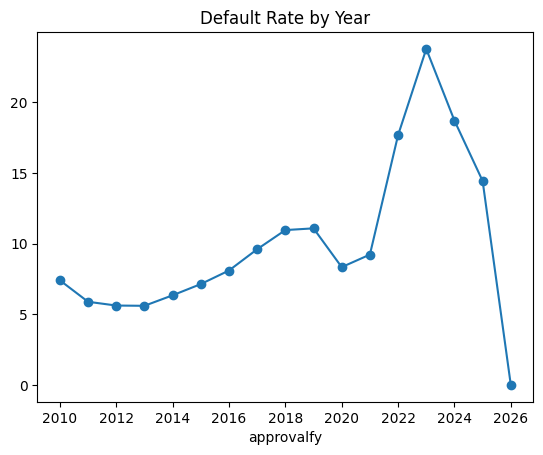

In [11]:
# 1. Calculate default rate
yearly_defaults = df.groupby('approvalfy')['target'].mean() * 100

# 2. Plot with one line
yearly_defaults.plot(kind='line', marker='o', title='Default Rate by Year')

<Axes: title={'center': 'Default Rate by Industry Sector (%)'}, xlabel='naics_sector'>

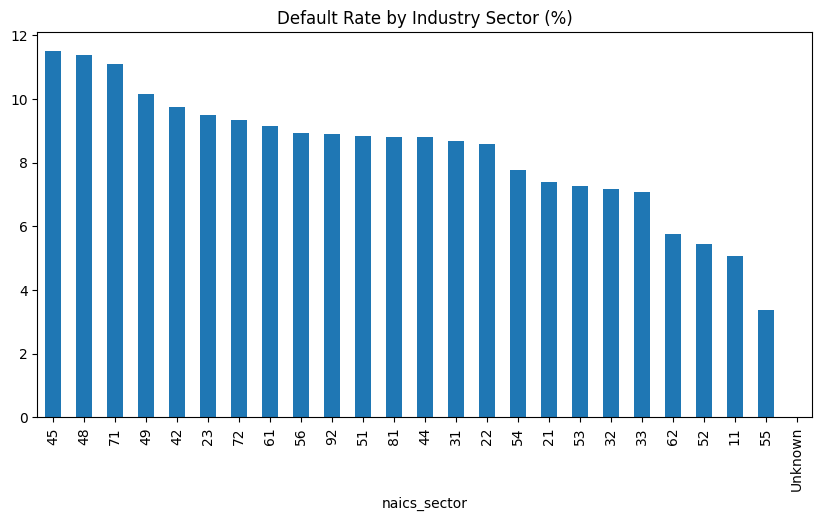

In [13]:
sector_defaults = df.groupby('naics_sector')['target'].mean() * 100
sector_defaults.sort_values(ascending=False).plot(kind='bar', figsize=(10, 5), title='Default Rate by Industry Sector (%)')

<Axes: title={'center': 'Default Rate by SBA Guarantee Percentage (%)'}, xlabel='sba_guarantee_ratio'>

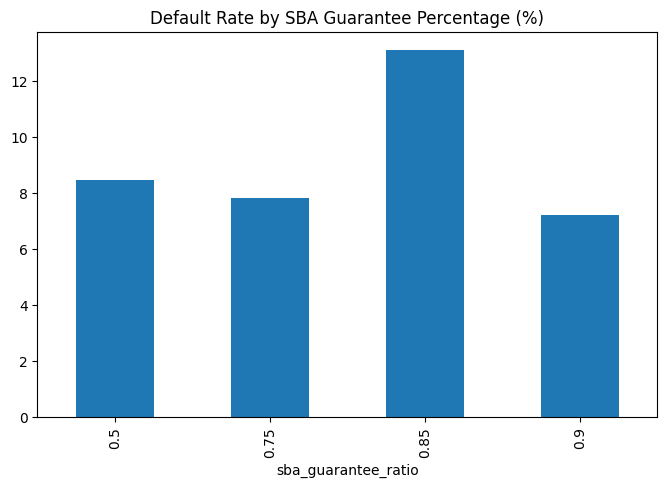

In [15]:
df['sba_guarantee_ratio'] = df['sbaguaranteedapproval'] / df['grossapproval']
guar_defaults = df.groupby(df['sba_guarantee_ratio'].round(2))['target'].mean() * 100

common_guar = df['sba_guarantee_ratio'].round(2).value_counts()
valid_guar = common_guar[common_guar > 1000].index
guar_defaults = guar_defaults.loc[valid_guar].sort_index()

guar_defaults.plot(kind='bar', figsize=(8, 5), title='Default Rate by SBA Guarantee Percentage (%)')

### 4. Moral Hazard Analysis (Guarantee Ratio vs. Defaults)
* **Hypothesis:** Higher government guarantees lead to laxer bank underwriting and higher default rates.
* **Finding:** Loans with a **75% guarantee** have a **7.8% default rate**, while loans with an **85% guarantee** spike to a **13.1% default rate**. This provides strong empirical evidence supporting the moral hazard theory in government-backed lending programs.

<Axes: title={'center': 'Default Rate by Business Age Group (%)'}, xlabel='business_age_group'>

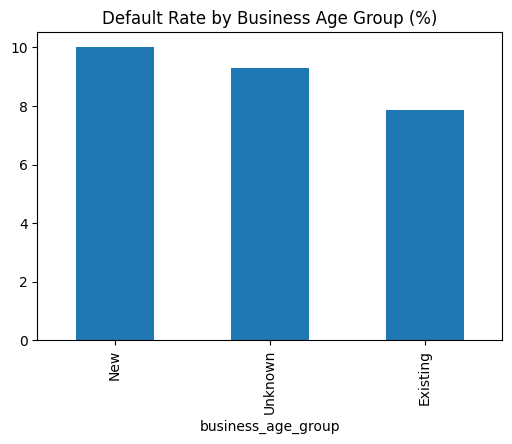

In [16]:
age_defaults = df.groupby('business_age_group')['target'].mean() * 100

age_defaults.sort_values(ascending=False).plot(kind='bar', figsize=(6, 4), title='Default Rate by Business Age Group (%)')